In [38]:
import numpy as np
import pandas as pd
import os, re, glob
from scipy.stats import ecdf
from scipy.stats import gaussian_kde
import sys

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.tri as mtri
matplotlib.rcParams['figure.dpi'] = 360
# matplotlib.rcParams['text.usetex'] = True
# os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
# plt.style.use('default')
cmap = sns.color_palette('mako', as_cmap=True)

In [39]:
fns = glob.glob('data/results/rosette_*.csv')
fns = sorted(fns, key=lambda x: int(re.search(r'rosette_(\d+)\.csv$', x).group(1)))

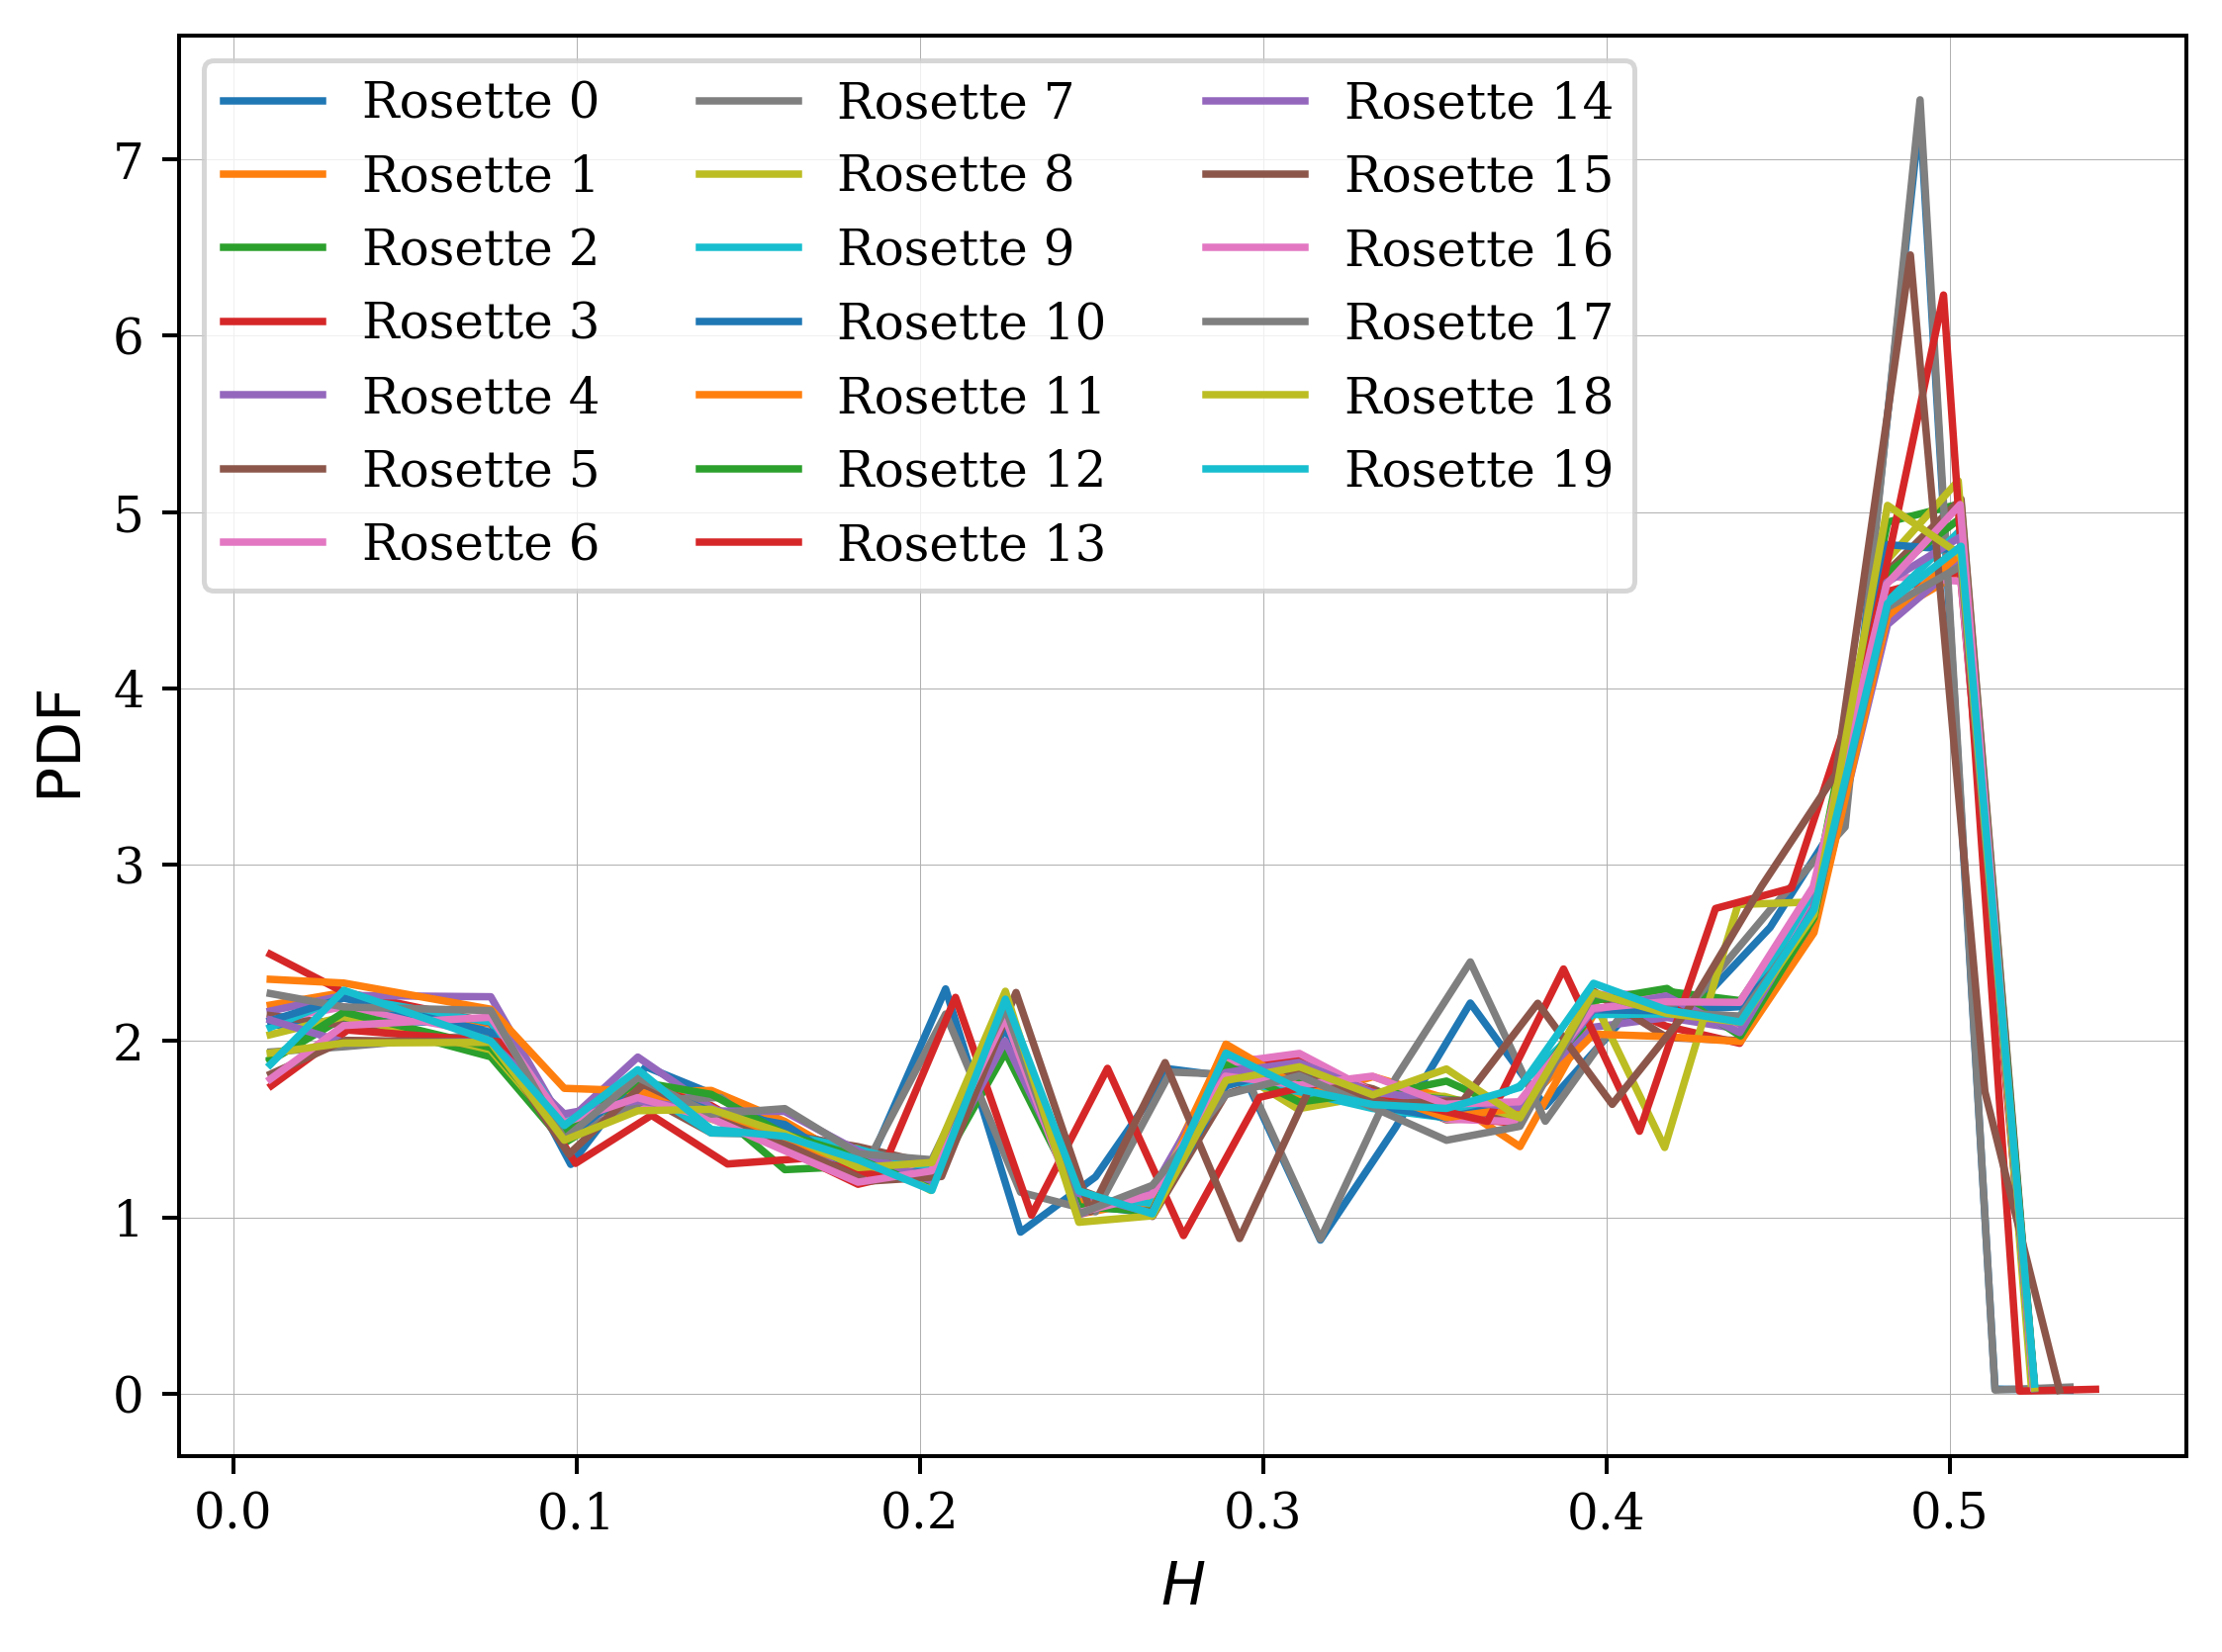

In [129]:
fig, ax = plt.subplots()
ax.grid(linewidth=0.2)

for f in fns:
    df = pd.read_csv(f)
    H = df['H'].values

    pdf, edges = np.histogram(H, bins=25, density=True)
    centers = 0.5*(edges[:-1] + edges[1:])

    rosette = int(re.search(r'rosette_(\d+)\.csv$', f).group(1))

    mask = pdf > 0
    plt.plot(centers[mask], pdf[mask], label=f'Rosette {rosette}')

plt.xlabel('$H$')
plt.ylabel(r'$\mathrm{PDF}$')
plt.legend(ncol=3, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

Clustering

In [56]:
cat_dir = os.path.join('data', 'catalogs')

pattern = os.path.join(cat_dir, 'rosette_*_catalog_all.csv')
files = sorted(glob.glob(pattern))

props = ['N', 'SIGMA_X', 'SIGMA_Y', 'SIGMA_Z', 'SIGMA_R']

In [57]:
len(files)

20

In [134]:
all_logR = []
for f in files:
    df = pd.read_csv(f)
    print(df[df['1']==])
    
all_logR = np.concatenate(all_logR)

Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['2'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['2'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')
Index(['1'], dtype='object')


ValueError: need at least one array to concatenate

In [84]:
bin_edges = np.linspace(all_logR.min(), all_logR.max(), 50)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [140]:
#!/usr/bin/env python3
import os
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# IMPORT DE FUNCIONES FoF
from src.make_web_catalog import find_fof_groups

# Codificación de web types
WEBTYPE_MAP = {'void':0, 'sheet':1, 'filament':2, 'peak':3}


def load_classification(results_dir, rosette):
    """
    Carga el fichero `rosette_{rosette}_catalog_all.csv`,
    que contiene un entero por línea (0,1,2,3).
    """
    path = os.path.join(results_dir, f'rosette_{rosette}_catalog_all.csv')
    # Leemos sin cabecera, cada fila un entero
    web = pd.read_csv(path, header=None, squeeze=True).astype(int).values
    return web


def load_positions(coord_dir, rosette):
    """Carga las posiciones 3D (X,Y,Z) de ELG_{rosette}_clustering_data.ecsv."""
    data_path = os.path.join(coord_dir, f'ELG_{rosette}_clustering_data.ecsv')
    df = pd.read_csv(data_path, comment='#', sep=r'\s+', engine='python')
    return df[['X','Y','Z']].values


def load_pairs(results_dir, rosette):
    """Carga el fichero de pares FoF `rosette_{rosette}_pairs.txt`."""
    path = os.path.join(results_dir, f'rosette_{rosette}_pairs.txt')
    return np.loadtxt(path, dtype=int)


def main():
    p = argparse.ArgumentParser(description="PCA + FoF group plotting")
    p.add_argument('--rosette',    type=int,   required=True,  help='ID de la roseta')
    p.add_argument('--webtype',    type=str,   required=True,
                   choices=WEBTYPE_MAP.keys(), help='Tipo: void, sheet, filament o peak')
    p.add_argument('--coord_dir',  type=str,   default='data/coord',   help='Carpeta con ECSV de data/rand')
    p.add_argument('--results_dir',type=str,   default='data/catalogs',help='Carpeta con pos/counts/pairs/all')
    p.add_argument('--output',     type=str,   default='figures/fof_groups.png', 
                   help='Archivo PNG de salida')
    args = p.parse_args()

    # 1) Cargo posiciones y clasificación “all”
    coords = load_positions(args.coord_dir, args.rosette)
    web    = load_classification(args.results_dir, args.rosette)
    wt_id  = WEBTYPE_MAP[args.webtype]

    # 2) Índices de puntos del tipo seleccionado
    type_idx = np.where(web == wt_id)[0]
    if type_idx.size == 0:
        raise RuntimeError(f"No hay puntos {args.webtype} en roseta {args.rosette}")

    # 3) Cargo pairs y filtro sólo aquellos entre puntos del tipo
    pairs = load_pairs(args.results_dir, args.rosette)
    mask  = np.isin(pairs[:,0], type_idx) & np.isin(pairs[:,1], type_idx)
    subp  = pairs[mask]

    # 4) Agrupo con FoF
    fof = find_fof_groups(subp)
    if not fof:
        raise RuntimeError(f"Ningún grupo FoF para {args.webtype} en roseta {args.rosette}")

    # 5) PCA 2D de todas las posiciones
    pca  = PCA(n_components=2)
    proj = pca.fit_transform(coords)

    # 6) Dibujo
    plt.figure(figsize=(8,8))
    # Todos los puntos en gris
    plt.scatter(proj[:,0], proj[:,1], s=5, color='lightgray', label='all data')

    # Cada grupo FoF con color distinto
    cmap = plt.get_cmap('tab20')
    for gid, members in fof.items():
        pts = proj[members]
        plt.scatter(pts[:,0], pts[:,1], s=20, color=cmap(gid % 20),
                    edgecolor='k', label=f'group {gid}')

    plt.title(f'Roseta {args.rosette} — FoF groups ({args.webtype})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(loc='center left', bbox_to_anchor=(1,0.5), markerscale=2)
    plt.tight_layout()

    # Guardar y mostrar
    os.makedirs(os.path.dirname(args.output), exist_ok=True)
    plt.savefig(args.output, dpi=300)
    print(f'Figura guardada en {args.output}')
    plt.show()